# **Potential Visualization Notebook**  

This notebook provides a structured workflow for analyzing and visualizing the **Chiral Potential** that we aim to develop to model the **empirical one** with DFTB. The analysis is conducted using modular Python scripts.

---

## Workflow Overview   

1. **Modified Lennard Jones Potential** – the implementation of cos() term to consider rotation of particles.
2. **Chiral Potential Visualization** – Adding the effect of reletive facing, more that global rotation to consider chirality effect on pair interaction.


---
# Potential Models for Molecular Dynamics Simulation

## 1. Chiral Potential Development

### Current Modified Lennard-Jones Potential
We previously introduced a modified Lennard-Jones potential with an angular term to control rotational periodicity:

$$
U_{\text{LJ,mod}} = 4\epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] + A(r) \left( 1 + \cos(n \Delta \phi + \alpha) \right)
$$

where $A(r) = \frac{A_0}{r^m}$ is the distance-dependent angular coupling strength.

### Chiral Potential Extension
To introduce chirality into our system, we must account for the handedness and orientation of each particle, as well as their relative spatial arrangement.

#### Key Physical Considerations:
1. **Handedness** ($h$): Right-handed (R = +1) or left-handed (L = -1)
2. **Orientation** ($d$): Up (U = +1) or down (D = -1) 
3. **Relative positioning**: The angle between particles affects their interaction

#### Mathematical Formulation:

1. **Relative angle between particles**:
   $$
   \gamma_{ij} = \arctan2\left( y_j - y_i, x_j - x_i \right)
   $$

2. **Chirality-corrected orientations**:
   $$
   \phi_{i,\text{eff}} = h_i d_i (\phi_i - \gamma_{ij})
   $$
   $$
   \phi_{j,\text{eff}} = h_j d_j (\phi_j - \gamma_{ji})
   $$
   
   where $\gamma_{ji} = \gamma_{ij} + \pi$

3. **Effective phase difference**:
   $$
   \Delta \phi_{\text{eff}} = \phi_{j,\text{eff}} - \phi_{i,\text{eff}}
   $$

#### Final Chiral Potential:
$$
U_{\text{LJ,chiral}} = 4\epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] + A(r) \left( 1 + \cos(n \Delta \phi_{\text{eff}} + \alpha) \right)
$$

**Implementation Parameters:**
- $h_i \in \{-1, +1\}$: Handedness of particle $i$
- $d_i \in \{-1, +1\}$: Orientation direction of particle $i$
- $n$: Rotational symmetry order
- $\alpha$: Phase offset
- $A_0, m$: Angular coupling parameters

In [ ]:
import visualization

heatmap_potential, heatmap_potential_polar = visualization.create_interactive_plots_LJmod()
display(heatmap_potential, heatmap_potential_polar)

In [ ]:
import visualization

heatmap_potential_chiral = visualization.create_interactive_plots_LJmod_pair()
display(heatmap_potential_chiral)

---
## 2. Field Coupled Potential

#### Alternative Chiral Potential Formulation
To explore a more flexible implementation of chirality, we introduce a coupling between particle rotation and relative position through a linear chiral term added to the standard Lennard-Jones (LJ) interaction:

$$
U_{\text{mod}} = U_{\text{LJ}} + V, \quad \text{where} \quad U_{\text{LJ}} = 4 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right]
$$

#### Chirality-Inducing Interaction Term
The chiral coupling is implemented via:

$$
V = v_i Q_j + v_j Q_i
$$

with:
- $ v_i = F(r, \psi_i) \cdot Q(\psi_i) $
- $ \psi_i = \phi_i - \gamma $
- $ \gamma = \arctan2(y_j - y_i, x_j - x_i) $

Here, $\psi_i$ describes the rotation of particle $i$ relative to the connecting line between particles $i$ and $j$.

#### Example Functional Forms
To keep the model general, $F$ and $Q$ can be freely chosen. In our default implementation, we use:

- Orientation-dependent modulation:
  $$
  Q(\psi) = \sin(\psi)
  $$

- Distance-dependent decay:
  $$
  F(r, \psi) = \frac{C}{r^m}
  $$

Thus, the full chiral interaction becomes:

$$
V = \frac{C}{r^m} \left[ \sin(\psi_i) \sin(\psi_j) + \sin(\psi_j) \sin(\psi_i) \right] = \frac{2C}{r^m} \sin(\psi_i) \sin(\psi_j)
$$

#### Final Potential Expression
Putting everything together:

$$
U_{\text{mod}} = 4 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] + \frac{2C}{r^m} \sin(\psi_i) \sin(\psi_j)
$$

---

#### Implementation Notes
- $ \phi_i $: Absolute orientation of particle $ i $
- $ \gamma $: Angle of inter-particle vector (chirality reference axis)
- $ C $: Chiral interaction strength


In [ ]:
import visualization

heatmap_potential, heatmap_potential_polar = visualization.create_interactive_chiral_new(pot_kwargs={'field_kwargs':{'period':3}})
display(heatmap_potential, heatmap_potential_polar)

In [ ]:
import numpy as np
#potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair(pot_kwargs={'field_kwargs':{'period':3}, 'charge':lambda psi2: np.sin((np.pi - psi2)*18)})
potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair(pot_kwargs={'field_kwargs':{'period':6}})
display(potential_chiral_pair)

In [ ]:
import visualization

import numpy as np
potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair_psi(pot_kwargs={'field_kwargs':{'period':3}, 'charge':lambda psi2: np.sin((np.pi/2 - psi2)*18)})
#potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair_psi(pot_kwargs={'field_kwargs':{'period':6}})
display(potential_chiral_pair)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lennard_jones_base(r, sigma=1, epsilon=1):
    if np.any(r <= 0):
        raise ValueError("Distance r must be greater than zero.")
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def r_LJ (xi, yi, xj, yj, phi_i=0, phi_j=0, radius=1):
    x = xj - xi + radius * (np.cos(phi_j) - np.cos(phi_i))
    y = yj - yi + radius * (np.sin(phi_j) - np.sin(phi_i))

    r = x**2 + y**2

    return np.sqrt(r)

d = 1.3
data = r_LJ(0, 0, np.array(d, d * np.cos(0: 2 * np.pi)), np.array(d, d * np.sin(0: 2 * np.pi)))
data2 = lennard_jones_base(r_LJ)

plt.heatmap(data2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets

def lennard_jones_base(r, sigma=1, epsilon=1):
    """Calculate the Lennard-Jones potential."""
    if np.any(r <= 0):
        return np.inf
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def r_LJ(xi, yi, xj, yj, phi_i=0, phi_j=0, radius=1):
    """Calculate the effective distance considering rotation."""
    x = xj - xi + radius * (np.cos(phi_j) - np.cos(phi_i))
    y = yj - yi + radius * (np.sin(phi_j) - np.sin(phi_i))
    return np.sqrt(x**2 + y**2)

# Parameters
sigma = 1.0
epsilon = 1.0
radius = 0.5

def plot_potential_LJ_in(d, phi_i, phi_j):
    theta = np.linspace(0, 2* np.pi, 100)

    xi, yi = 0, 0
    xj, yj = d*np.cos(theta), d*np.sin(theta)
    Xj, Yj = np.meshgrid(xj, yj)

    effective_distances = r_LJ(xi, yi, Xj, Yj, phi_i, phi_j, radius)
    potential = lennard_jones_base(effective_distances, sigma, epsilon)

    D, Theta = np.meshgrid(d, theta)
    
    fig, axs = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))
      
    # Plot the heatmap
    c1 = axs.contourf(Theta, D, potential, levels=100, cmap="viridis")
    fig.colorbar(c1, ax=axs, label='Potential')

    plt.title('Modified Lennard-Jones Potential')

    plt.grid(False)
    plt.tight_layout()
    plt.show()

def interactive_plot_LJ_in():
    distance_slider = ipywidgets.FloatSlider(value=1.8, min=1, max=5, step=0.1, description='Centers Distance:')
    phi_i_slider = ipywidgets.FloatSlider(value=0, min=0, max=2*np.pi, step=np.pi/8, description='φ_i:')
    phi_j_slider = ipywidgets.FloatSlider(value=0, min=0, max=2*np.pi, step=np.pi/8, description='φ_j:')
    
    heatmap_potential = ipywidgets.interactive(
        plot_potential_LJ_in,
        d=distance_slider,
        phi_i=phi_i_slider,
        phi_j=phi_j_slider
    )
    
    return heatmap_potential

potential_LJ_in = interactive_plot_LJ_in()
display(potential_LJ_in)

---

## 3. Geometric Patch-Based Potential

### Concept
This potential model treats particles as rigid bodies with discrete interaction patches representing amino acid positions in polypeptide molecules. The total interaction energy combines:
1. Center-to-center Lennard-Jones repulsion (excluded volume)
2. Patch-to-patch Lennard-Jones attractions (specific interactions)

### Mathematical Formulation

#### Total Potential:
$$
U_{ij} = U_{\text{LJ}}(R_{ij}) + \sum_{n=0}^{N-1} U_{\text{LJ}}(r_{ij}^{(n)})
$$

where:
- $R_{ij}$: Distance between particle centers
- $r_{ij}^{(n)}$: Distance between patch $n$ of particles $i$ and $j$
- $N$: Total number of patches per particle

#### Geometric Relations:

**Patch positions:**
$$
\vec{r}_i^{(n)} = \vec{R}_i + \rho \left( \cos\theta_i^{(n)} \hat{x} + \sin\theta_i^{(n)} \hat{y} \right)
$$

where:
- $\rho$: Patch radius (distance from center to patch)
- $\theta_i^{(n)} = \phi_i + \frac{2\pi n}{N}$: Angular position of patch $n$ on particle $i$
- $\phi_i$: Orientation angle of particle $i$

**Inter-patch distances:**
$$
\vec{r}_{ij}^{(n)} = \vec{r}_j^{(n)} - \vec{r}_i^{(n)}
$$

$$
r_{ij}^{(n)} = |\vec{r}_{ij}^{(n)}| = \sqrt{(x_j - x_i + \rho\Delta\cos^{(n)})^2 + (y_j - y_i + \rho\Delta\sin^{(n)})^2}
$$

where:
$$
\Delta\cos^{(n)} = \cos\theta_j^{(n)} - \cos\theta_i^{(n)}
$$
$$
\Delta\sin^{(n)} = \sin\theta_j^{(n)} - \sin\theta_i^{(n)}
$$

#### Physical Interpretation:
- The center-to-center term prevents particle overlap
- Patch-to-patch terms provide orientation-dependent attraction
- Each patch interacts only with its corresponding patch on other particles
- The model captures the discrete nature of molecular interactions while maintaining computational efficiency

#### Implementation Notes:
- Patches are equally spaced around each particle's perimeter
- The potential naturally favors specific relative orientations
- Computational complexity scales as $O(N)$ per particle pair

---

### Force Calculation

The forces and torques are obtained by taking derivatives of the potential energy with respect to particle coordinates and orientations.

#### Force Derivation

**Total Force on Particle $i$:**
$$
\vec{F}_i = -\nabla_{\vec{R}_i} U_{ij} = -\frac{\partial U_{ij}}{\partial \vec{R}_i}
$$

**Torque on Particle $i$:**
$$
\tau_i = -\frac{\partial U_{ij}}{\partial \phi_i}
$$

#### Center-to-Center Force Contribution

The standard Lennard-Jones force between particle centers:
$$
\vec{F}_{\text{center}} = -\frac{\partial U_{\text{LJ}}(R_{ij})}{\partial \vec{R}_i} = F_{\text{LJ}}(R_{ij}) \frac{\vec{R}_{ij}}{R_{ij}}
$$

where:
$$
F_{\text{LJ}}(r) = \frac{24\epsilon}{r} \left[ 2\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]
$$

#### Patch-Based Force Contributions

For each patch pair $(i,n)$ and $(j,n)$:

**Translational Force:**
$$
\vec{F}_{\text{patch}}^{(n)} = -\frac{\partial U_{\text{LJ}}(r_{ij}^{(n)})}{\partial \vec{r}_{ij}^{(n)}} \frac{\partial \vec{r}_{ij}^{(n)}}{\partial \vec{R}_i}
$$

Since $\frac{\partial \vec{r}_{ij}^{(n)}}{\partial \vec{R}_i} = -\hat{I}$ (negative identity matrix), we get:
$$
\vec{F}_{\text{patch}}^{(n)} = F_{\text{LJ}}(r_{ij}^{(n)}) \frac{\vec{r}_{ij}^{(n)}}{r_{ij}^{(n)}}
$$

**Rotational Force (Torque):**
The torque arises from the dependence of patch positions on particle orientation:
$$
\tau_{\text{patch}}^{(n)} = -\frac{\partial U_{\text{LJ}}(r_{ij}^{(n)})}{\partial r_{ij}^{(n)}} \frac{\partial r_{ij}^{(n)}}{\partial \phi_i}
$$

The geometric derivative is:
$$
\frac{\partial r_{ij}^{(n)}}{\partial \phi_i} = \frac{1}{r_{ij}^{(n)}} \vec{r}_{ij}^{(n)} \cdot \frac{\partial \vec{r}_{ij}^{(n)}}{\partial \phi_i}
$$

where:
$$
\frac{\partial \vec{r}_{ij}^{(n)}}{\partial \phi_i} = -\rho \left( -\sin\theta_i^{(n)} \hat{x} + \cos\theta_i^{(n)} \hat{y} \right)
$$

This gives the torque contribution:
$$
\tau_{\text{patch}}^{(n)} = F_{\text{LJ}}(r_{ij}^{(n)}) \frac{\rho}{r_{ij}^{(n)}} \left[ -\sin\theta_i^{(n)} (x_j - x_i + \rho\Delta\cos^{(n)}) + \cos\theta_i^{(n)} (y_j - y_i + \rho\Delta\sin^{(n)}) \right]
$$

#### Total Force and Torque

**Total Translational Force:**
$$
\vec{F}_i = \vec{F}_{\text{center}} + \sum_{n=0}^{N-1} \vec{F}_{\text{patch}}^{(n)}
$$

**Total Torque:**
$$
\tau_i = \sum_{n=0}^{N-1} \tau_{\text{patch}}^{(n)}
$$

#### Alternative Torque Calculation (Cross Product Method)

The torque can also be computed using the cross product between patch position vectors and patch forces:
$$
\tau_i = \sum_{n=0}^{N-1} \vec{r}_{\text{patch},i}^{(n)} \times \vec{F}_{\text{patch}}^{(n)}
$$

where $\vec{r}_{\text{patch},i}^{(n)} = \rho(\cos\theta_i^{(n)}, \sin\theta_i^{(n)})$ is the vector from particle center to patch $n$.

In 2D, the cross product gives the z-component:
$$
\tau_i = \sum_{n=0}^{N-1} \left[ \rho\cos\theta_i^{(n)} F_{y,\text{patch}}^{(n)} - \rho\sin\theta_i^{(n)} F_{x,\text{patch}}^{(n)} \right]
$$

#### Computational Implementation

The force calculation algorithm:

1. **Initialize** force and torque accumulators to zero
2. **Calculate center-to-center contribution** using standard LJ force
3. **For each patch pair** $(n = 0, 1, ..., N-1)$:
   - Compute inter-patch distance $r_{ij}^{(n)}$
   - Apply cutoff check
   - Calculate patch force magnitude $F_{\text{LJ}}(r_{ij}^{(n)})$
   - Add translational force contribution
   - Add torque contribution using cross product method
4. **Return** total force vector and torque

#### Force Symmetry

By Newton's third law:
- $\vec{F}_j = -\vec{F}_i$ (force on particle $j$ is opposite to force on particle $i$)
- The torque on particle $j$ must be calculated separately by swapping particle roles

#### Physical Insights

- **Alignment tendency**: Patches create torques that favor specific relative orientations
- **Distance dependence**: Both forces and torques decrease rapidly with distance (r⁻⁷ for LJ)
- **Orientation coupling**: Translational and rotational motions are naturally coupled through patch geometry
- **Stability**: The model tends to form ordered structures where patches are optimally aligned


---

## 4. Patchy Potential (Inspired by Patchy Colloid Particles)

### Concept
This potential model combines isotropic Lennard-Jones interactions with anisotropic patch-based attractions. The model is inspired by patchy colloidal particles where:
1. Hard-core repulsion prevents particle overlap (standard LJ repulsion)
2. Attractive patches create directional interactions through Gaussian angular factors
3. The angular dependence favors specific orientational alignments between particles

### Mathematical Formulation

#### Total Potential:
The potential has different forms depending on the inter-particle distance:

**For $r < \sigma_{\text{LJ}}$ (repulsive region):**
$$
U_{ij}(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]
$$

**For $\sigma_{\text{LJ}} \leq r \leq r_{\text{cutoff}}$ (attractive region):**
$$
U_{ij}(r, \{\phi\}) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] \times \Lambda_{\text{ang}}(\{\phi\})
$$

**For $r > r_{\text{cutoff}}$:**
$$
U_{ij}(r) = 0
$$

#### Angular Modulation Factor:
The angular factor $\Lambda_{\text{ang}}$ determines the orientational dependence:

$$
\Lambda_{\text{ang}}(\phi) = \sum_{n=0}^{N_{\text{patch}}-1} \exp\left(-\frac{\theta_{i,n}^2}{2\sigma_{\text{ang}}^2}\right) \exp\left(-\frac{\theta_{j,n}^2}{2\sigma_{\text{ang}}^2}\right)
$$

where:
- $N_{\text{patch}}$: Number of patches per particle
- $\sigma_{\text{ang}}$: Angular width parameter (controls patch selectivity)
- $\theta_{i,n}$: Alignment angle for patch $n$ on particle $i$
- $\theta_{j,n}$: Alignment angle for patch $n$ on particle $j$

#### Geometric Relations:

**Inter-particle vector:**
$$
\vec{R}_{ij} = \vec{R}_j - \vec{R}_i = (x_j - x_i, y_j - y_i)
$$

**Connection angle:**
$$
\gamma_{ij} = \arctan2(y_j - y_i, x_j - x_i)
$$

**Patch directions:**
$$
\psi_{i,n} = \phi_i + \frac{2\pi n}{N_{\text{patch}}}
$$
$$
\psi_{j,n} = \phi_j + \frac{2\pi n}{N_{\text{patch}}}
$$

**Alignment angles:**
$$
\theta_{i,n} = \psi_{i,n} - \gamma_{ij}
$$
$$
\theta_{j,n} = \psi_{j,n} - \gamma_{ji} = \psi_{j,n} - (\gamma_{ij} + \pi)
$$

#### Alternative Formulation (Minimum Angle Selection):
In the original patchy colloid model, instead of summing over all patches, the optimal patch alignment is selected:

$$
\Lambda_{\text{ang}}^{\text{min}}(\phi) = \exp\left(-\frac{\theta_{kij}^2}{2\sigma_{\text{ang}}^2}\right) \exp\left(-\frac{\theta_{lij}^2}{2\sigma_{\text{ang}}^2}\right)
$$

This formulation selects the patch pair that provides the strongest attraction.

#### Physical Interpretation:
- **Isotropic repulsion**: Prevents particle overlap regardless of orientation
- **Anisotropic attraction**: Only activated when patches are properly aligned
- **Gaussian angular dependence**: Provides smooth transitions between aligned and misaligned states
- **Patch selectivity**: Parameter $\sigma_{\text{ang}}$ controls how precisely patches must be aligned
- **Orientational ordering**: The potential naturally promotes specific relative orientations

#### Key Parameters:
- $\epsilon$: Energy scale (attraction strength)
- $\sigma$: Length scale (particle size)
- $\sigma_{\text{LJ}}$: Transition point between repulsive and attractive regions
- $r_{\text{cutoff}}$: Maximum interaction range
- $\sigma_{\text{ang}}$: Angular selectivity (smaller values = more selective patches)
- $N_{\text{patch}}$: Number of patches per particle

#### Implementation Notes:
- The potential is discontinuous at $r = \sigma_{\text{LJ}}$ (step function behavior)
- For smooth potentials, consider using a switching function instead of sharp cutoffs
- The angular factor $\Lambda_{\text{ang}} \geq 0$ ensures the attractive region remains attractive
- Computational complexity: $O(N_{\text{patch}}^2)$ for minimum selection, $O(N_{\text{patch}})$ for summation
- The model reduces to standard Lennard-Jones when $\Lambda_{\text{ang}} = 1$

#### Comparison with Geometric Model:
| Feature | Patchy Potential | Geometric Potential |
|---------|------------------|-------------------|
| Patch representation | Angular modulation | Explicit spatial positions |
| Computational cost | Lower | Higher |
| Physical realism | Phenomenological | More geometric |
| Parameter tuning | Easier | More complex |
| Orientational coupling | Smooth (Gaussian) | Sharp (distance-based) |

---

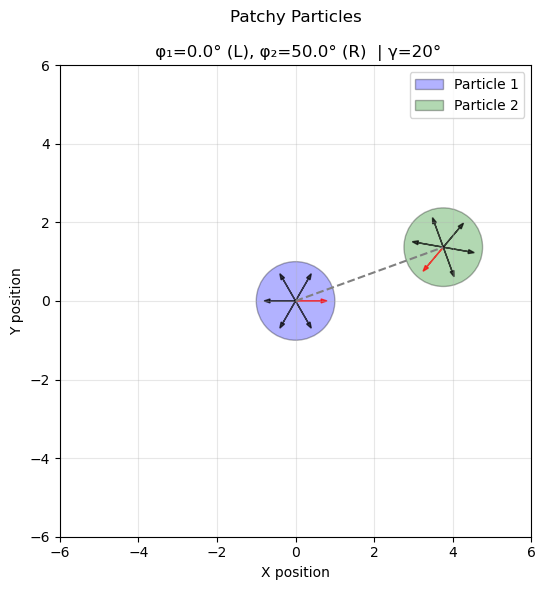

In [25]:
import numpy as np
import matplotlib.pyplot as plt


def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def calculate_patch_orientations(particle_angle, handedness, patch_angles):
    if handedness.upper() == 'R':
        return particle_angle + patch_angles
    return particle_angle - patch_angles


def find_best_patch_angles(phi_i, h_i, phi_j, h_j, gamma, patch_angles):

    theta_i = calculate_patch_orientations(phi_i, h_i, patch_angles)
    theta_j = calculate_patch_orientations(phi_j, h_j, patch_angles)
                 
    rel_i = wrap_angle(theta_i - gamma)
    rel_j = wrap_angle(theta_j - (gamma + np.pi))

    best_i = np.argmin(np.abs(rel_i))
    best_j = np.argmin(np.abs(rel_j))

    return theta_i, theta_j, best_i, best_j


def plot_particles_with_patches(phi_i, h_i, phi_j, h_j, patch_angles, gamma_deg):

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    
    R = 1.0
    D = 4.0
    gamma = np.radians(gamma_deg)

    pos_i = np.array([0, 0])
    pos_j = D * np.array([np.cos(gamma), np.sin(gamma)])

    theta_i, theta_j, best_i, best_j = find_best_patch_angles(phi_i, h_i, phi_j, h_j, gamma, patch_angles)

    circle_i = plt.Circle(pos_i, R, edgecolor='black', facecolor='blue', alpha=0.3, label='Particle 1')
    circle_j = plt.Circle(pos_j, R, edgecolor='black', facecolor='green', alpha=0.3, label='Particle 2')
    
    ax.add_patch(circle_i)
    ax.add_patch(circle_j)

    def plot_patches(position, angles, best_idx, color):
        for n, angle in enumerate(angles):
            vec = R * 0.8 * np.array([np.cos(angle), np.sin(angle)])
            patch_color = 'red' if n == best_idx else 'black'
            ax.arrow(
                *position, *vec, 
                head_width=0.1, 
                color=patch_color, 
                length_includes_head=True,
                alpha=0.7
            )
    
    plot_patches(pos_i, theta_i, best_i, 'blue')
    plot_patches(pos_j, theta_j, best_j, 'green')

    ax.plot([pos_i[0], pos_j[0]], [pos_i[1], pos_j[1]], 'gray', linestyle='--')

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_title(f'Patchy Particles\n\n φ₁={np.degrees(phi_i):.1f}° ({h_i}), φ₂={np.degrees(phi_j):.1f}° ({h_j})  | γ={gamma_deg}°')
    ax.set_xlabel('X position')
    ax.set_ylabel('Y position')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    
    phi1 = np.radians(0)
    h1 = 'L'
    phi2 = np.radians(50)
    h2 = 'R'
    patch_angles = np.array([0, np.pi/3, 2*np.pi/3, 3*np.pi/3, 4*np.pi/3, 5*np.pi/3])
    gamma_deg = 20

    plot_particles_with_patches(phi1, h1, phi2, h2, patch_angles, gamma_deg)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

def wrap_angle(angle):
    """Wrap angle to [-π, π]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi

def patch_directions(phi, N):
    """Return absolute patch directions for a given particle orientation."""
    return phi + 2 * np.pi * np.arange(N) / N

def find_best_patch_angles(phi1, phi2, gamma, N):
    """
    For given particle orientations (phi1, phi2), direction gamma between them,
    and number of patches N, return minimum angles between patches and connecting line.
    """
    theta_i_all = patch_directions(phi1, N)
    theta_j_all = patch_directions(phi2, N)

    # Relative angles to r_ij and -r_ij
    theta_i_rel = wrap_angle(theta_i_all - gamma)
    theta_j_rel = wrap_angle(theta_j_all - (gamma + np.pi))

    # Get smallest angle (best matching patch)
    theta_i_min = theta_i_rel[np.argmin(np.abs(theta_i_rel))]
    theta_j_min = theta_j_rel[np.argmin(np.abs(theta_j_rel))]

    return theta_i_min, theta_j_min

def patchy_LJ_potential(r, theta_i, theta_j, epsilon=1.0, sigma_LJ=1.0, sigma_theta=np.pi/12):
    """Patchy Lennard-Jones potential with angular modulation."""
    lj = 4 * epsilon * ((sigma_LJ / r)**12 - (sigma_LJ / r)**6)
    angular = np.exp(-theta_i**2 / (2 * sigma_theta**2)) * np.exp(-theta_j**2 / (2 * sigma_theta**2))
    return lj * angular

def interactive_plot(phi2_slider=0.0, N_slider=4):
    phi1 = 0.0                  # orientation of particle i
    gamma = np.pi / 3          # angle between particles
    N = N_slider               # number of patches
    phi2 = phi2_slider         # orientation of particle j

    r_vals = np.linspace(0.8, 3.0, 300)

    theta_i, theta_j = find_best_patch_angles(phi1, phi2, gamma, N)
    U_vals = patchy_LJ_potential(r_vals, theta_i, theta_j)

    plt.figure(figsize=(8, 5))
    plt.plot(r_vals, U_vals, color='royalblue')
    plt.xlabel('Distance $r$')
    plt.ylabel('Potential $U(r)$')
    plt.title(f'Patchy LJ Potential (φ₂ = {phi2:.2f} rad, N = {N})')
    plt.grid(True)
    plt.ylim(-1.5, 1.0)
    plt.show()

interact(
    interactive_plot,
    phi2_slider=FloatSlider(min=0, max=2*np.pi, step=0.1, value=0.0, description='phi₂'),
    N_slider=IntSlider(min=2, max=12, step=1, value=4, description='# Patches')
)


interactive(children=(FloatSlider(value=0.0, description='phi₂', max=6.283185307179586), IntSlider(value=4, de…

<function __main__.interactive_plot(phi2_slider=0.0, N_slider=4)>

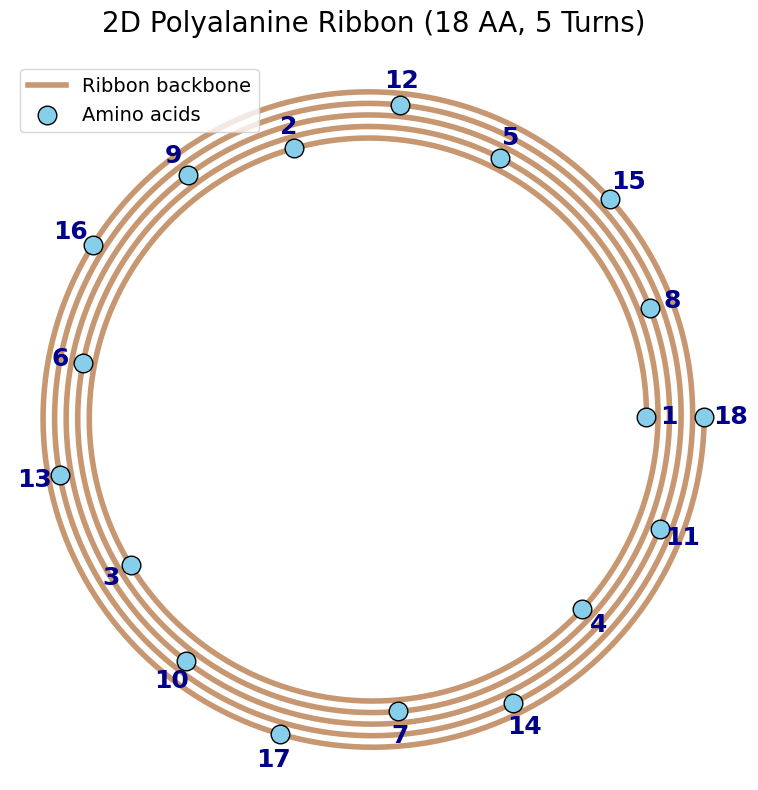

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_amino = 18
n_turns = 5
r_start = 0.15 
r_step = 0.001      

thetas = np.linspace(0, 2 * np.pi * n_turns, n_amino)
radii = r_start + r_step * thetas

# Spiral path
t_spiral = np.linspace(0, 2 * np.pi * n_turns, 3000)
r_spiral = r_start + r_step * t_spiral
x_spiral = r_spiral * np.cos(t_spiral)
y_spiral = r_spiral * np.sin(t_spiral)

# Amino acids
x = radii * np.cos(thetas)
y = radii * np.sin(thetas)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_spiral, y_spiral, color='#c79771', lw=4, zorder=1, label='Ribbon backbone')
ax.scatter(x, y, s=180, color='skyblue', edgecolor='k', zorder=2, label='Amino acids')

for i in range(n_amino):
    ax.text(x[i]*1.08, y[i]*1.08, str(i+1), ha='center', va='center', fontsize=18, fontweight='bold', color='darkblue')

ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('2D Polyalanine Ribbon (18 AA, 5 Turns)', fontsize=20, pad=20)
ax.legend(loc='upper left', fontsize=14)
plt.tight_layout()
plt.show()

### Patchy Geometric Lennard-Jones based potential:

Position of particle i:
$$
\vec{C}_i = (x_i, y_i)
$$

Position of patch (1) on particle i:  
$$
\vec{C}_i^1 = (x_i + r \cos(\varphi_i^1),\; y_i + r \sin(\varphi_i^1))
$$

Patch-based force between two particles:  
$$
F_{LJ}(\vec{C}_i^1, \vec{C}_j^1) = F_{LJ}(x_i, y_i, \varphi_i, x_j, y_j, \varphi_j)
$$

Potential energy of particle i due to particle j:  
$$
V_i = V_{LJ}(\vec{C}_i^1, \vec{C}_j^1) = V_{LJ}(x_i, y_i, \varphi_i, x_j, y_j, \varphi_j) = V_{LJ}(d^1)
$$

Lennard-Jones potential:  
$$
V_{LJ}(d^1) = 4\epsilon \left[\left(\frac{\sigma}{d^1}\right)^{12} - \left(\frac{\sigma}{d^1}\right)^6\right]
$$

where:
$$
d^1 = \sqrt{(x_i + r \cos(\varphi_i^1) - x_j - r \cos(\varphi_j^1))^2 + (y_i + r \sin(\varphi_i^1) - y_j - r \sin(\varphi_j^1))^2}
$$

Resulting force on particle i:  
$$
V = V_i + V_j
$$
$$
\vec{F}_i = \left(-\frac{\partial V}{\partial x_i},\; -\frac{\partial V}{\partial y_i},\; -\frac{\partial V}{\partial \varphi_i}\right)
$$

---

Hamiltonian:  
$$
H = T + V
$$
$$
V = V_i + V_j
$$

Hamilton's equations:  
$$
\dot{p} = \frac{\partial H}{\partial q}
$$
$$
\dot{q} = \frac{\partial H}{\partial p}
$$

Kinetic energy:  
$$
T = \frac{1}{2} m_i \dot{C}_i^2 + \frac{1}{2} m_j \dot{C}_j^2 + \frac{1}{2} I_i \dot{\varphi}_i^2 + \frac{1}{2} I_j \dot{\varphi}_j^2
$$
or, in summation form:
$$
T = \frac{1}{2} \sum_k \frac{p_{k,xy}^2}{m_k} + \frac{1}{2} \sum_k \frac{p_{k,\varphi}^2}{I_k}
$$

where:
$$
p_{k,xy} = m_k \dot{C}_k
$$
$$
p_{k,\varphi} = I_k \dot{\varphi}_k
$$